In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.preprocessing import FunctionTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

In [2]:
# 1. Load Dataset
import os
# Robust path resolver for data/ directory
data_path = next((p for p in ['../data/Social_Network_Ads.csv', 'data/Social_Network_Ads.csv', 'Social_Network_Ads.csv'] if os.path.exists(p)), 'Social_Network_Ads.csv')
df = pd.read_csv(data_path)
print(f'Dataset Loaded successfully from: {data_path}')
print('Dataset Shape:', df.shape)
df.head()

Dataset Shape: (400, 5)


,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [3]:
df.tail()

,User ID,Gender,Age,EstimatedSalary,Purchased
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0
399,15594041,Female,49,36000,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


In [5]:
df.describe()

,User ID,Age,EstimatedSalary,Purchased
count,4.000000e+02,400.000000,400.000000,400.000000
mean,1.569154e+07,37.655000,69742.500000,0.357500
std,7.165832e+04,10.482877,34096.960282,0.479864
min,1.556669e+07,18.000000,15000.000000,0.000000
25%,1.562676e+07,29.750000,43000.000000,0.000000
50%,1.569434e+07,37.000000,70000.000000,0.000000
75%,1.575036e+07,46.000000,88000.000000,1.000000
max,1.581524e+07,60.000000,150000.000000,1.000000


In [6]:
# Missing Values Analysis
df.isnull().sum().sort_values(ascending=False)

User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

In [7]:
# Remove Duplicates
print("Original dataset shape:", df.shape)
df = df.drop_duplicates()
print("After removing duplicates:", df.shape)

Original dataset shape: (400, 5)
After removing duplicates: (400, 5)


In [8]:
# Target Class Distribution
print("============================== TARGET CLASS DISTRIBUTION ==============================")
print(df["Purchased"].value_counts(normalize=True))

============================== TARGET CLASS DISTRIBUTION ==============================
Purchased
0    0.6425
1    0.3575
Name: proportion, dtype: float64


## 2.5 Exploratory Data Analysis (EDA) & Visualizations
In this section, we deeply analyze the underlying distributions, demographic interactions, and decision boundaries between customers who purchased the advertised product versus those who did not.

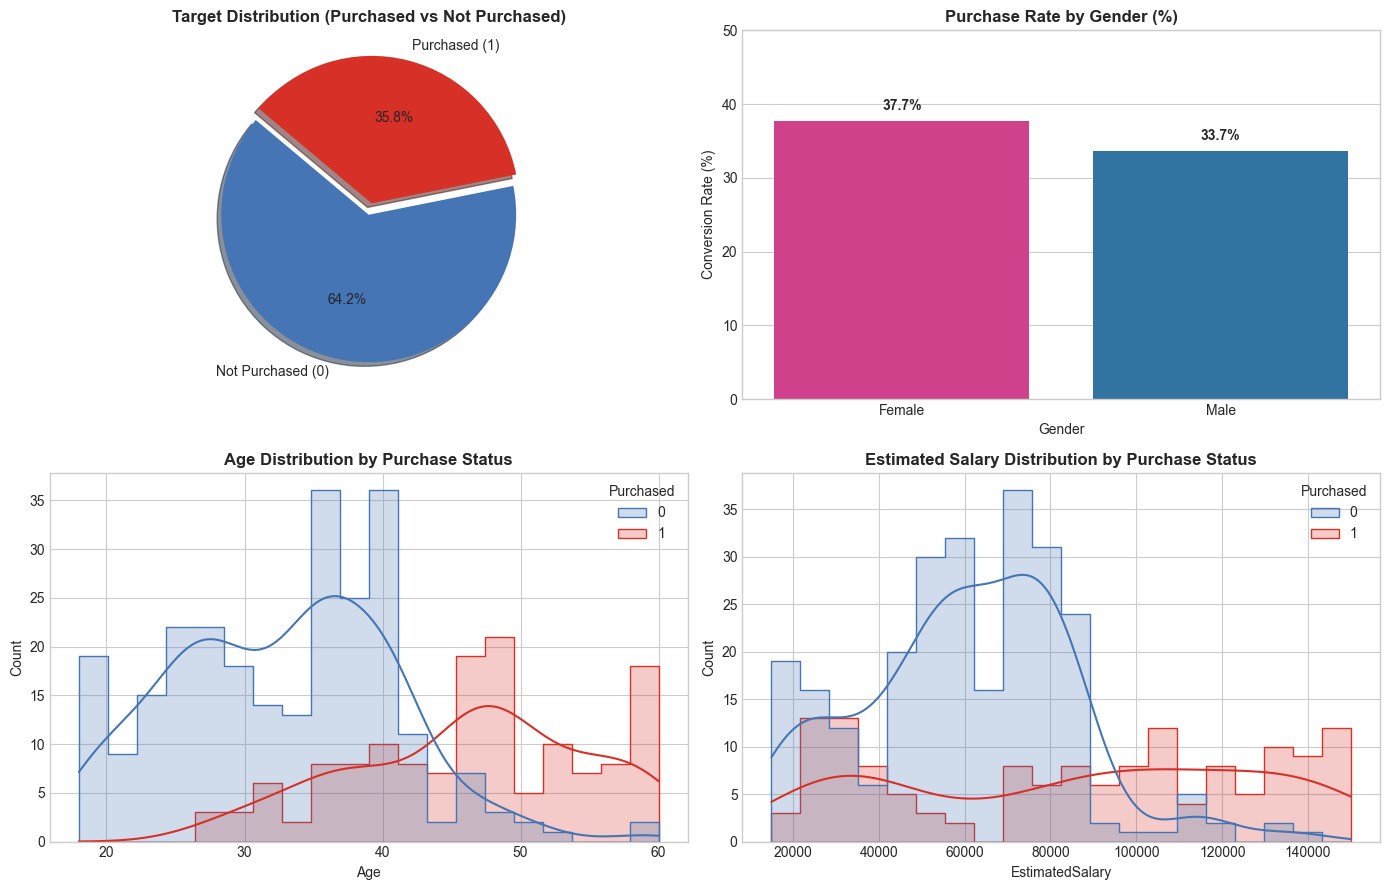

In [9]:
# 2.5.1 Demographics and Target Distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Target count & ratio
counts = df["Purchased"].value_counts()
axes[0, 0].pie(counts, labels=["Not Purchased (0)", "Purchased (1)"], autopct="%1.1f%%",
               startangle=140, colors=["#4575b4", "#d73027"], explode=[0, 0.08], shadow=True)
axes[0, 0].set_title("Target Distribution (Purchased vs Not Purchased)", weight="bold")

# Gender vs Purchase Rate
gender_rate = df.groupby("Gender")["Purchased"].mean() * 100
sns.barplot(x=gender_rate.index, y=gender_rate.values, ax=axes[0, 1], palette=["#e7298a", "#1f78b4"], hue=gender_rate.index, legend=False)
axes[0, 1].set_title("Purchase Rate by Gender (%)", weight="bold")
axes[0, 1].set_ylabel("Conversion Rate (%)")
axes[0, 1].set_ylim(0, 50)
for p in axes[0, 1].patches:
    axes[0, 1].annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height() + 1),
                        ha='center', va='bottom', weight='bold')

# Age Distribution by Purchase
sns.histplot(data=df, x="Age", hue="Purchased", kde=True, ax=axes[1, 0], palette=["#4575b4", "#d73027"],
             element="step", common_norm=False, bins=20)
axes[1, 0].set_title("Age Distribution by Purchase Status", weight="bold")

# Estimated Salary by Purchase
sns.histplot(data=df, x="EstimatedSalary", hue="Purchased", kde=True, ax=axes[1, 1], palette=["#4575b4", "#d73027"],
             element="step", common_norm=False, bins=20)
axes[1, 1].set_title("Estimated Salary Distribution by Purchase Status", weight="bold")

plt.tight_layout()
plt.show()

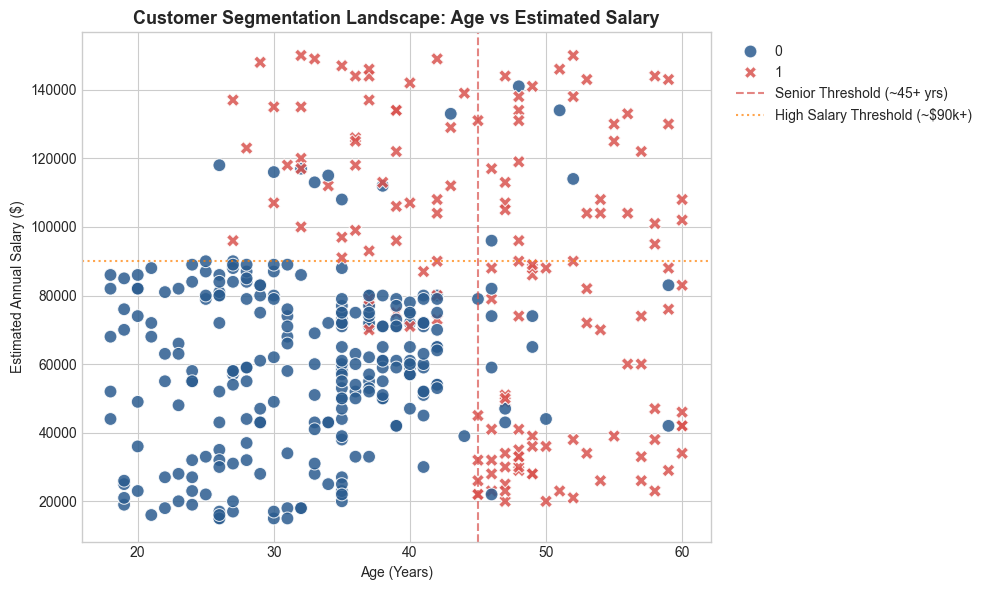

In [10]:
# 2.5.2 Bivariate Decision Landscape (Age vs Estimated Salary)
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="Age",
    y="EstimatedSalary",
    hue="Purchased",
    style="Purchased",
    palette=["#2b5c8f", "#d9534f"],
    s=85,
    alpha=0.85
)
plt.axvline(45, color="#d9534f", linestyle="--", alpha=0.7, label="Senior Threshold (~45+ yrs)")
plt.axhline(90000, color="#ff7f00", linestyle=":", alpha=0.7, label="High Salary Threshold (~$90k+)")
plt.title("Customer Segmentation Landscape: Age vs Estimated Salary", weight="bold", fontsize=13)
plt.xlabel("Age (Years)")
plt.ylabel("Estimated Annual Salary ($)")
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

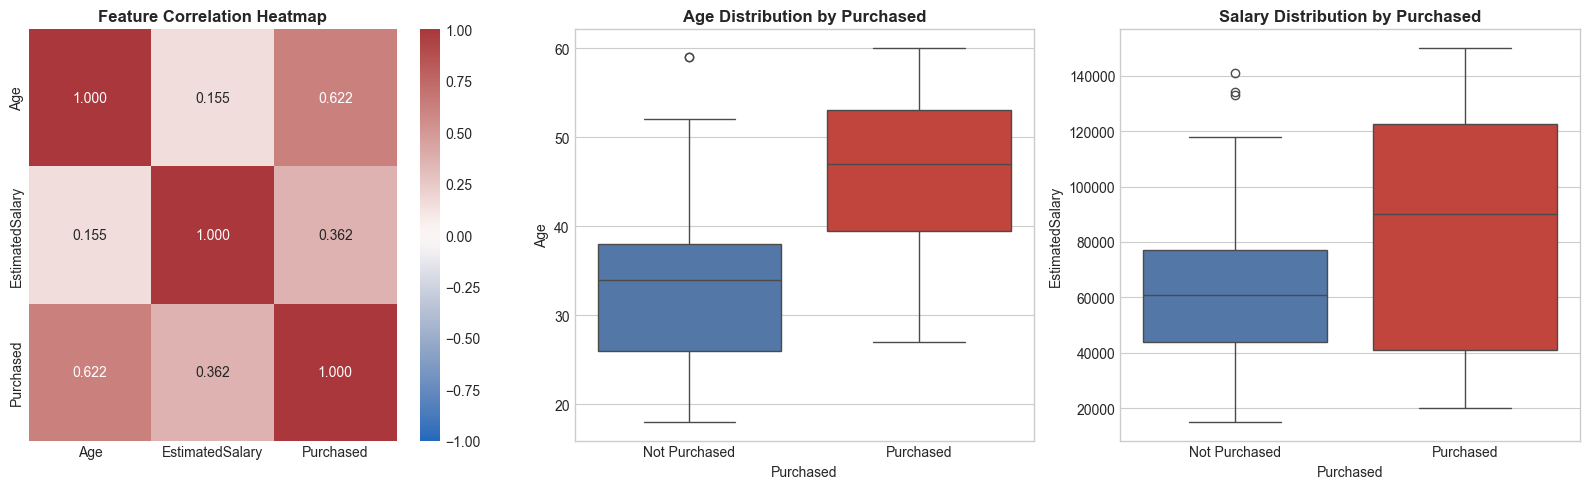

In [11]:
# 2.5.3 Correlation Heatmap & Boxplots
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

corr = df[["Age", "EstimatedSalary", "Purchased"]].corr()
sns.heatmap(corr, annot=True, fmt=".3f", cmap="vlag", vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title("Feature Correlation Heatmap", weight="bold")

sns.boxplot(x="Purchased", y="Age", data=df, ax=axes[1], palette=["#4575b4", "#d73027"], hue="Purchased", legend=False)
axes[1].set_title("Age Distribution by Purchased", weight="bold")
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["Not Purchased", "Purchased"])

sns.boxplot(x="Purchased", y="EstimatedSalary", data=df, ax=axes[2], palette=["#4575b4", "#d73027"], hue="Purchased", legend=False)
axes[2].set_title("Salary Distribution by Purchased", weight="bold")
axes[2].set_xticks([0, 1])
axes[2].set_xticklabels(["Not Purchased", "Purchased"])

plt.tight_layout()
plt.show()

In [12]:
# 3. Separate Features and Target (Dropping User ID metadata)
X_raw = df.drop(columns=["Purchased", "User ID"])
y = df["Purchased"]


In [13]:
# ==========================================================================
# 4. TRAIN-TEST SPLIT FIRST (Stratified Split)
# ==========================================================================
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("== STRATIFIED SPLIT COMPLETED FIRST ==")
print(f"Training instances: {X_train_raw.shape[0]} (Purchase rate: {y_train.mean()*100:.1f}%)")
print(f"Testing instances:  {X_test_raw.shape[0]} (Purchase rate: {y_test.mean()*100:.1f}%)")


== STRATIFIED SPLIT COMPLETED FIRST ==
Training instances: 320 (Purchase rate: 35.6%)
Testing instances:  80 (Purchase rate: 36.2%)


In [14]:
# ==========================================================================
# 5. FEATURE ENGINEERING (Applied AFTER Split)
# ==========================================================================
def engineer_features(df_in):
    d = df_in.copy()
    d["Salary_Per_Age"] = d["EstimatedSalary"] / (d["Age"] + 1e-5)
    d["Is_Senior"] = (d["Age"] >= 45).astype(int)
    d["High_Salary"] = (d["EstimatedSalary"] >= 90000).astype(int)
    d["Salary_Age_Product"] = d["EstimatedSalary"] * d["Age"]
    return d

X_train = engineer_features(X_train_raw)
X_test  = engineer_features(X_test_raw)
print("Engineered features ready. Train shape:", X_train.shape, "Test shape:", X_test.shape)


Engineered features ready. Train shape: (320, 7) Test shape: (80, 7)


In [15]:
# 6. Identify Numerical and Categorical Features
all_numeric = X_train.select_dtypes(include=["int64", "float64", "int32"]).columns.tolist()
categorical_features = ["Gender"]

# Automatically separate binary indicator features (0/1) from continuous numeric features
binary_features = [col for col in all_numeric if set(X_train[col].dropna().unique()).issubset({0, 1})]
continuous_numeric = [col for col in all_numeric if col not in binary_features]

print(f"\nContinuous numerical features ({len(continuous_numeric)}):", continuous_numeric)
print(f"Binary indicator features ({len(binary_features)}):", binary_features)
print("Categorical features:", categorical_features)


Continuous numerical features (4): ['Age', 'EstimatedSalary', 'Salary_Per_Age', 'Salary_Age_Product']
Binary indicator features (2): ['Is_Senior', 'High_Salary']
Categorical features: ['Gender']


In [16]:
# Temporary copy for calculating skewness
X_train_cont = X_train[continuous_numeric].copy()
# Median imputation ONLY for calculating skewness
X_train_cont = X_train_cont.fillna(X_train_cont.median())
skewness = X_train_cont.skew()
print("\nSkewness of continuous numerical features:")
print(skewness.sort_values(ascending=False))


Skewness of continuous numerical features:
Salary_Age_Product    1.075827
Salary_Per_Age        0.616558
EstimatedSalary       0.478982
Age                   0.277209
dtype: float64


In [17]:
log_features = []
for col in continuous_numeric:
    if X_train_cont[col].min() >= 0:
        if abs(skewness[col]) > 1:
            log_features.append(col)
regular_numeric_features = [
    col
    for col in continuous_numeric
    if col not in log_features
]
print("\nLog-transformed features:", log_features)
print("\nRegular numerical features:", regular_numeric_features)
print("\nBinary features (passthrough without scaling):", binary_features)


Log-transformed features: ['Salary_Age_Product']

Regular numerical features: ['Age', 'EstimatedSalary', 'Salary_Per_Age']

Binary features (passthrough without scaling): ['Is_Senior', 'High_Salary']


In [18]:
# Preprocessing Pipelines & ColumnTransformer
log_numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("log", FunctionTransformer(np.log1p, validate=False)),
    ("scaler", RobustScaler())
])

regular_numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())
])

binary_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent"))
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("log_numeric", log_numeric_pipeline, log_features),
    ("regular_numeric", regular_numeric_pipeline, regular_numeric_features),
    ("binary", binary_pipeline, binary_features),
    ("categorical", categorical_pipeline, categorical_features)
])

In [19]:
# Curated Models
models = {
    "Logistic Regression (Parametric Baseline)": LogisticRegression(C=1.0, random_state=42),
    "Support Vector Machine (RBF Kernel Boundary)": SVC(C=1.0, kernel='rbf', probability=True, random_state=42),
    "Random Forest Classifier (Bagging)": RandomForestClassifier(n_estimators=100, max_depth=5, min_samples_leaf=2, random_state=42),
    "Gradient Boosting Classifier (Boosting Champion)": GradientBoostingClassifier(n_estimators=100, learning_rate=0.08, max_depth=3, random_state=42)
}


In [20]:
# 8. Train, Cross-Validate, Predict, and Evaluate Curated Classification Pipelines
results = []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, classifier in models.items():
    model = Pipeline([("preprocessing", preprocessor), ("classifier", classifier)])
    
    # 5-Fold Stratified Cross-Validation
    cv_scores = cross_validate(model, X_train, y_train, cv=cv, scoring=["roc_auc", "accuracy", "f1"])
    cv_roc_mean = cv_scores["test_roc_auc"].mean()
    cv_roc_std = cv_scores["test_roc_auc"].std()
    cv_acc_mean = cv_scores["test_accuracy"].mean()
    cv_f1_mean = cv_scores["test_f1"].mean()
    
    # Hold-out Test Set evaluation
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_prob)
    cm = confusion_matrix(y_test, y_pred)
    
    print("\n======================================")
    print(f" {name} Results")
    print("======================================")
    print(f"5-Fold CV Accuracy: {cv_acc_mean * 100:.2f}%")
    print(f"5-Fold CV F1-Score: {cv_f1_mean * 100:.2f}%")
    print(f"5-Fold CV ROC-AUC : {cv_roc_mean:.4f} (+/- {cv_roc_std:.4f})")
    print(f"Test Accuracy     : {accuracy * 100:.2f}%")
    print(f"Test Precision    : {precision * 100:.2f}%")
    print(f"Test Recall       : {recall * 100:.2f}%")
    print(f"Test F1-Score     : {f1 * 100:.2f}%")
    print(f"Test ROC-AUC      : {roc_auc:.4f}")
    print("\nConfusion Matrix:")
    print(cm)
    
    results.append({
        "Model": name,
        "CV Accuracy (%)": f"{cv_acc_mean * 100:.2f}%",
        "CV ROC-AUC": f"{cv_roc_mean:.4f} (±{cv_roc_std:.3f})",
        "Test Accuracy (%)": f"{accuracy * 100:.2f}%",
        "Test Precision (%)": f"{precision * 100:.2f}%",
        "Test Recall (%)": f"{recall * 100:.2f}%",
        "Test F1-Score (%)": f"{f1 * 100:.2f}%",
        "Test ROC-AUC": f"{roc_auc:.4f}"
    })


 Logistic Regression (Parametric Baseline) Results
5-Fold CV Accuracy: 92.50%
5-Fold CV F1-Score: 90.01%
5-Fold CV ROC-AUC : 0.9572 (+/- 0.0080)
Test Accuracy     : 90.00%
Test Precision    : 83.87%
Test Recall       : 89.66%
Test F1-Score     : 86.67%
Test ROC-AUC      : 0.9500

Confusion Matrix:
[[46  5]
 [ 3 26]]

 Support Vector Machine (RBF Kernel Boundary) Results
5-Fold CV Accuracy: 92.19%
5-Fold CV F1-Score: 89.69%
5-Fold CV ROC-AUC : 0.9469 (+/- 0.0254)
Test Accuracy     : 88.75%
Test Precision    : 81.25%
Test Recall       : 89.66%
Test F1-Score     : 85.25%
Test ROC-AUC      : 0.9344

Confusion Matrix:
[[45  6]
 [ 3 26]]

 Random Forest Classifier (Bagging) Results
5-Fold CV Accuracy: 91.25%
5-Fold CV F1-Score: 88.20%
5-Fold CV ROC-AUC : 0.9581 (+/- 0.0164)
Test Accuracy     : 88.75%
Test Precision    : 83.33%
Test Recall       : 86.21%
Test F1-Score     : 84.75%
Test ROC-AUC      : 0.9506

Confusion Matrix:
[[46  5]
 [ 4 25]]

 Gradient Boosting Classifier (Boosting Champi

In [21]:
# 9. Consolidated Summary Table
summary_df = pd.DataFrame(results).sort_values(by="Test ROC-AUC", ascending=False)
print("\n==================================== FINAL MODEL PERFORMANCE RANKING ====================================")
print(summary_df.to_string(index=False))


==================================== FINAL MODEL PERFORMANCE RANKING ====================================
                                           Model CV Accuracy (%)      CV ROC-AUC Test Accuracy (%) Test Precision (%) Test Recall (%) Test F1-Score (%) Test ROC-AUC
Gradient Boosting Classifier (Boosting Champion)          88.75% 0.9546 (±0.010)            88.75%             83.33%          86.21%            84.75%       0.9523
              Random Forest Classifier (Bagging)          91.25% 0.9581 (±0.016)            88.75%             83.33%          86.21%            84.75%       0.9506
       Logistic Regression (Parametric Baseline)          92.50% 0.9572 (±0.008)            90.00%             83.87%          89.66%            86.67%       0.9500
    Support Vector Machine (RBF Kernel Boundary)          92.19% 0.9469 (±0.025)            88.75%             81.25%          89.66%            85.25%       0.9344
